In [23]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from pydantic import SecretStr,BaseModel , Field 
from typing import TypedDict,NotRequired,Annotated, Literal
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
import operator
# from langgraph.graph.message import add_messages
# from langgraph.checkpoint.memory import MemorySaver 
# from langgraph.checkpoint.sqlite import SqliteSaver
# import sqlite3
# from langgraph.prebuilt import ToolNode , tools_condition
# from langchain_community.tools.ddg_search import DuckDuckGoSearchRun
# from langchain_core.tools import tool
# import requests
# from langgraph.checkpoint.postgres import PostgresSaver
# from langgraph.store.memory import InMemoryStore
# from langchain_core.runnables import RunnableConfig
# from langgraph.store.base import BaseStore
from langgraph.types import Send

from dotenv import load_dotenv

load_dotenv()

llm = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite",
    api_key = SecretStr(os.environ["GOOGLE_API_KEY"]),
)


In [24]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [25]:
class Plan(BaseModel):
    blog_title: str
    tasks: list[Task]

In [26]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[list[str], operator.add]
    final: str

In [27]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [28]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [29]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).text.strip()

    return {"sections": [section_md]}

In [30]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    import re
    slug = re.sub(r"[^a-z0-9]+", "_", title.lower()).strip("_")
    output_path = Path.cwd() / (slug + ".md")
    output_path.write_text(final_md, encoding="utf-8")
    print(f"Saved blog to: {output_path} ({len(final_md)} chars)")

    return {"final": final_md}

In [31]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

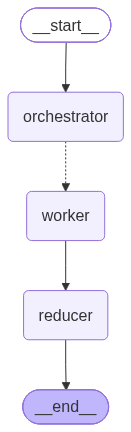

In [32]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [33]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})
out


{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention: The Engine Behind Modern Transformers', tasks=[Task(id=1, title='Introduction to Attention Mechanisms', brief='Define the concept of attention in neural networks and why it was developed to solve limitations of RNNs.'), Task(id=2, title='The Mechanics of Self-Attention', brief='Explain the Query, Key, and Value vectors and how they interact to calculate attention scores.'), Task(id=3, title='The Mathematical Formulation', brief='Break down the softmax function and the matrix multiplication process used to derive attention weights.'), Task(id=4, title='Multi-Head Attention', brief='Discuss why running multiple attention heads in parallel allows models to focus on different aspects of a sequence simultaneously.'), Task(id=5, title='Advantages Over Traditional Architectures', brief='Contrast self-attention with recurrent and convolutional layers regarding long-range dependencies and paralle